# DEVIXO SOLUTIONS
# DATA SCIENCE INTERNSHIP PROGRAM
# TASK 01 - EXPLORATORY DATA ANALYSIS (EDA)
# SUPERMARKET SALES DATASET

In [1]:
# 1. IMPORT LIBRARIES


import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Plot style
sns.set_theme(style="whitegrid")

In [2]:
# 2. LOAD DATASET


FILE_NAME = "supermarket_sales_eda_dataset.csv"

df = pd.read_csv("/content/supermarket_sales_eda_dataset.csv")

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
print(df.head())

print("\nLast 5 Records:")
print(df.tail())

DATASET LOADED SUCCESSFULLY

Dataset Shape:
(1503, 16)

First 5 Records:
  Invoice_ID        Date Branch       City Customer_type  Gender  \
0  INV-01000  2025-01-01      B   Mandalay        Member  Female   
1  INV-00780  2025-01-01      B   Mandalay        Member    Male   
2  INV-00121  2025-01-01      C  Naypyitaw        Member  Female   
3  INV-00590  2025-01-01      A     Yangon        Member  Female   
4  INV-00483  2025-01-01      B   Mandalay        Member  Female   

          Product_line  Unit_price  Quantity  Discount  Tax_5pct  Total  \
0    Sports and travel       57.69        10      0.12     25.33 531.85   
1   Home and lifestyle       38.52         3      0.16      4.84 101.68   
2  Fashion accessories       35.90         5      0.08      8.25 173.21   
3    Health and beauty       19.03         2      0.16      1.60  33.65   
4   Food and beverages       27.85         8      0.17      9.22 193.70   

    COGS  Gross_income      Payment  Rating  
0 417.97        113.8

In [3]:
# 3. DATASET INFORMATION


print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
print(df.info())


DATASET INFORMATION

Column Names:
['Invoice_ID', 'Date', 'Branch', 'City', 'Customer_type', 'Gender', 'Product_line', 'Unit_price', 'Quantity', 'Discount', 'Tax_5pct', 'Total', 'COGS', 'Gross_income', 'Payment', 'Rating']

Data Types:
Invoice_ID        object
Date              object
Branch            object
City              object
Customer_type     object
Gender            object
Product_line      object
Unit_price       float64
Quantity           int64
Discount         float64
Tax_5pct         float64
Total            float64
COGS             float64
Gross_income     float64
Payment           object
Rating           float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     1503 non-null   object 
 1   Date           1503 non-null   object 
 2   Branch         1503 non-null   object 


In [4]:
# 4. CONVERT DATE COLUMN
# ============================================================

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [5]:
# 5. NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("\n" + "=" * 70)
print("NUMERICAL FEATURES")
print("=" * 70)

print(numerical_columns)

print("\n" + "=" * 70)
print("CATEGORICAL FEATURES")
print("=" * 70)

print(categorical_columns)


NUMERICAL FEATURES
['Unit_price', 'Quantity', 'Discount', 'Tax_5pct', 'Total', 'COGS', 'Gross_income', 'Rating']

CATEGORICAL FEATURES
['Invoice_ID', 'Branch', 'City', 'Customer_type', 'Gender', 'Product_line', 'Payment']


In [6]:
# 6. BASIC STATISTICAL INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

print(df.describe())

print("\nComplete Statistical Summary:")
print(df.describe(include="all"))


STATISTICAL SUMMARY
                                Date  Unit_price  Quantity  Discount  \
count                           1503    1,503.00  1,503.00  1,503.00   
mean   2025-07-02 09:31:01.077844480       56.50      5.54      0.10   
min              2025-01-01 00:00:00        8.52      1.00      0.00   
25%              2025-03-30 00:00:00       33.74      3.00      0.05   
50%              2025-07-04 00:00:00       56.93      6.00      0.10   
75%              2025-09-29 00:00:00       78.14      8.00      0.15   
max              2025-12-31 00:00:00      109.97     10.00      0.20   
std                              NaN       26.65      2.85      0.06   

       Tax_5pct    Total     COGS  Gross_income   Rating  
count  1,503.00 1,503.00 1,503.00      1,503.00 1,493.00  
mean      13.92   292.40   204.82         87.59     6.98  
min        0.39     8.18     5.79          0.95     4.00  
25%        5.66   118.83    83.75         31.21     6.20  
50%       11.42   239.81   169.30  

In [7]:
# 7. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES BEFORE CLEANING")
print("=" * 70)

missing_values = df.isnull().sum()

print(missing_values)




MISSING VALUES BEFORE CLEANING
Invoice_ID        0
Date              0
Branch            0
City              0
Customer_type    10
Gender            0
Product_line      0
Unit_price        0
Quantity          0
Discount          0
Tax_5pct          0
Total             0
COGS              0
Gross_income      0
Payment          10
Rating           10
dtype: int64


In [8]:
# 8. CHECK DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)



DUPLICATE RECORDS
Number of duplicate rows: 3


In [9]:
# 9. DATA CLEANING
# ============================================================

print("\n" + "=" * 70)
print("DATA CLEANING")
print("=" * 70)

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing categorical values
if df["Customer_type"].isnull().sum() > 0:
    df["Customer_type"] = df["Customer_type"].fillna(
        df["Customer_type"].mode()[0]
    )

if df["Payment"].isnull().sum() > 0:
    df["Payment"] = df["Payment"].fillna(
        df["Payment"].mode()[0]
    )

# Fill missing numerical values
if df["Rating"].isnull().sum() > 0:
    df["Rating"] = df["Rating"].fillna(
        df["Rating"].median()
    )

# Fix invalid values
df.loc[df["Quantity"] <= 0, "Quantity"] = df["Quantity"].median()

df.loc[df["Unit_price"] <= 0, "Unit_price"] = df["Unit_price"].median()

df.loc[df["Total"] <= 0, "Total"] = df["Total"].median()

# Rating should be between 0 and 10
df.loc[
    ~df["Rating"].between(0, 10),
    "Rating"
] = df["Rating"].median()



DATA CLEANING


In [10]:
# 10. VERIFY CLEANED DATA
# ============================================================

print("\n" + "=" * 70)
print("DATA AFTER CLEANING")
print("=" * 70)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning:")
print(df.duplicated().sum())


# Save cleaned dataset
df.to_csv(
    "cleaned_supermarket_sales.csv",
    index=False
)

print("\nCleaned dataset saved successfully.")


DATA AFTER CLEANING
Rows: 1500
Columns: 16

Missing Values After Cleaning:
Invoice_ID       0
Date             0
Branch           0
City             0
Customer_type    0
Gender           0
Product_line     0
Unit_price       0
Quantity         0
Discount         0
Tax_5pct         0
Total            0
COGS             0
Gross_income     0
Payment          0
Rating           0
dtype: int64

Duplicate Rows After Cleaning:
0

Cleaned dataset saved successfully.


In [11]:
# 11. FEATURE ENGINEERING
# ============================================================

df["Month"] = df["Date"].dt.month

df["Month_Name"] = df["Date"].dt.month_name()

df["Day"] = df["Date"].dt.day

df["Day_Name"] = df["Date"].dt.day_name()

df["Year"] = df["Date"].dt.year

df["Revenue"] = df["Total"]


In [12]:
# 12. FEATURE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("FEATURE ANALYSIS")
print("=" * 70)


# Minimum and maximum values

print("\nMinimum Values:")

print("Unit Price:",
      df["Unit_price"].min())

print("Quantity:",
      df["Quantity"].min())

print("Total:",
      df["Total"].min())

print("COGS:",
      df["COGS"].min())

print("Gross Income:",
      df["Gross_income"].min())

print("Rating:",
      df["Rating"].min())


print("\nMaximum Values:")

print("Unit Price:",
      df["Unit_price"].max())

print("Quantity:",
      df["Quantity"].max())

print("Total:",
      df["Total"].max())

print("COGS:",
      df["COGS"].max())

print("Gross Income:",
      df["Gross_income"].max())

print("Rating:",
      df["Rating"].max())


# Average values

print("\nAverage Values:")

print(
    df[
        [
            "Unit_price",
            "Quantity",
            "Total",
            "COGS",
            "Gross_income",
            "Rating"
        ]
    ].mean()
)






FEATURE ANALYSIS

Minimum Values:
Unit Price: 8.52
Quantity: 1
Total: 8.18
COGS: 5.79
Gross Income: 0.95
Rating: 4.0

Maximum Values:
Unit Price: 109.97
Quantity: 10
Total: 1107.21
COGS: 832.14
Gross Income: 380.16
Rating: 10.0

Average Values:
Unit_price      56.45
Quantity         5.54
Total          292.23
COGS           204.66
Gross_income    87.57
Rating           6.98
dtype: float64


In [13]:
 #13. CATEGORY ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("CATEGORY ANALYSIS")
print("=" * 70)


print("\nBranch:")
print(df["Branch"].value_counts())


print("\nCity:")
print(df["City"].value_counts())


print("\nCustomer Type:")
print(df["Customer_type"].value_counts())


print("\nGender:")
print(df["Gender"].value_counts())


print("\nProduct Line:")
print(df["Product_line"].value_counts())


print("\nPayment:")
print(df["Payment"].value_counts())




CATEGORY ANALYSIS

Branch:
Branch
A    549
B    502
C    449
Name: count, dtype: int64

City:
City
Yangon       549
Mandalay     502
Naypyitaw    449
Name: count, dtype: int64

Customer Type:
Customer_type
Member    832
Normal    668
Name: count, dtype: int64

Gender:
Gender
Female    762
Male      738
Name: count, dtype: int64

Product Line:
Product_line
Electronic accessories    287
Food and beverages        278
Home and lifestyle        259
Health and beauty         233
Fashion accessories       233
Sports and travel         210
Name: count, dtype: int64

Payment:
Payment
Cash           538
Ewallet        528
Credit card    434
Name: count, dtype: int64


In [14]:
# 14. OUTLIER ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("OUTLIER ANALYSIS")
print("=" * 70)

outlier_columns = [
    "Unit_price",
    "Quantity",
    "Total",
    "COGS",
    "Gross_income",
    "Rating"
]

for column in outlier_columns:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(
        f"{column}: {len(outliers)} outliers"
    )



OUTLIER ANALYSIS
Unit_price: 0 outliers
Quantity: 0 outliers
Total: 12 outliers
COGS: 24 outliers
Gross_income: 29 outliers
Rating: 0 outliers


In [15]:
# 15. CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)

correlation_columns = [
    "Unit_price",
    "Quantity",
    "Discount",
    "Tax_5pct",
    "Total",
    "COGS",
    "Gross_income",
    "Rating"
]

correlation_matrix = df[
    correlation_columns
].corr()

print(correlation_matrix)



CORRELATION ANALYSIS
              Unit_price  Quantity  Discount  Tax_5pct  Total  COGS  \
Unit_price          1.00     -0.05      0.00      0.63   0.63  0.62   
Quantity           -0.05      1.00     -0.04      0.66   0.66  0.65   
Discount            0.00     -0.04      1.00     -0.11  -0.11 -0.02   
Tax_5pct            0.63      0.66     -0.11      1.00   1.00  0.98   
Total               0.63      0.66     -0.11      1.00   1.00  0.98   
COGS                0.62      0.65     -0.02      0.98   0.98  1.00   
Gross_income        0.55      0.60     -0.28      0.91   0.91  0.81   
Rating             -0.02      0.00      0.00     -0.01  -0.01 -0.01   

              Gross_income  Rating  
Unit_price            0.55   -0.02  
Quantity              0.60    0.00  
Discount             -0.28    0.00  
Tax_5pct              0.91   -0.01  
Total                 0.91   -0.01  
COGS                  0.81   -0.01  
Gross_income          1.00   -0.02  
Rating               -0.02    1.00  


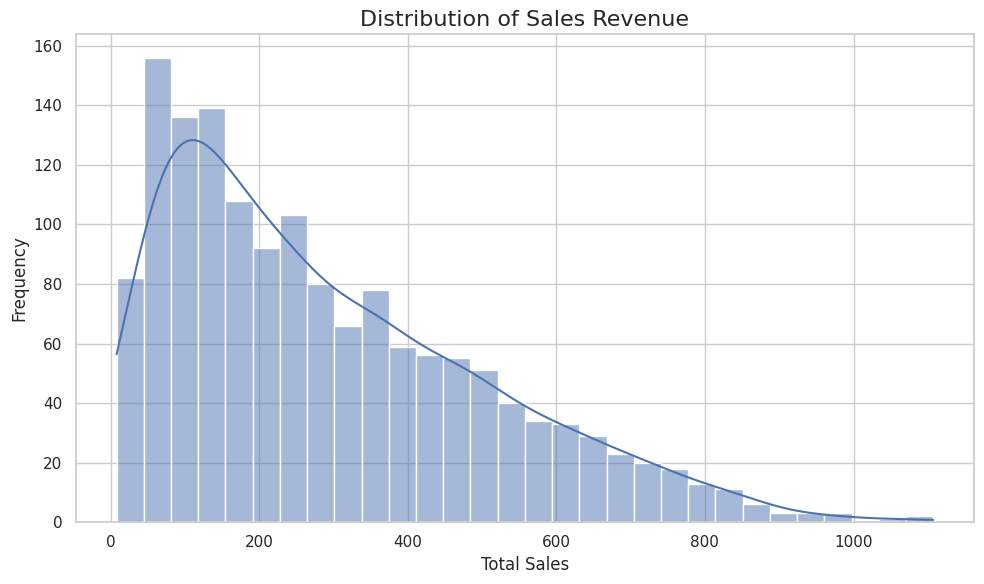

In [16]:
# 16. VISUALIZATION 1
# HISTOGRAM
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Total"],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Sales Revenue",
    fontsize=16
)

plt.xlabel("Total Sales")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()


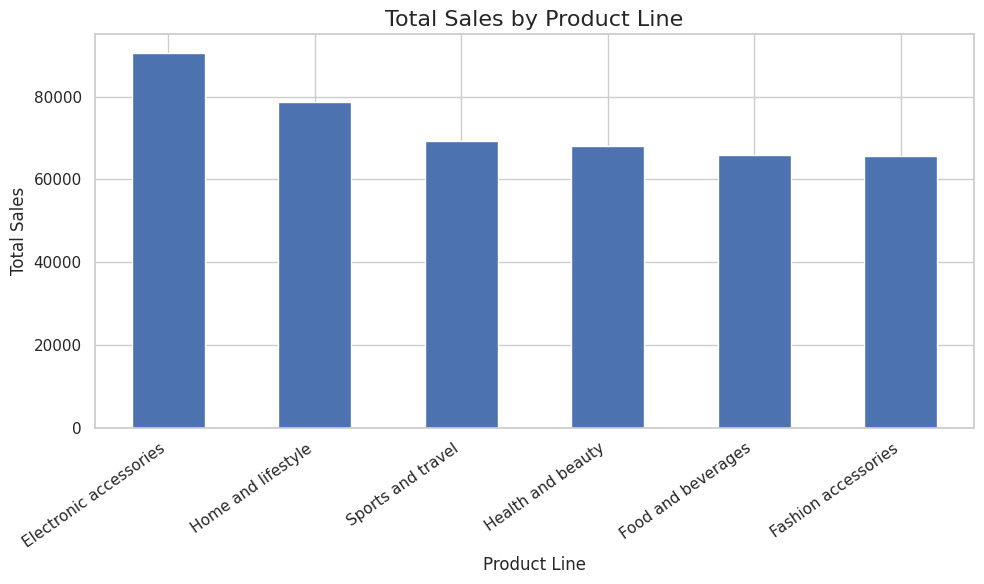

In [17]:
# 17. VISUALIZATION 2
# BAR CHART
# ============================================================

product_sales = (
    df.groupby("Product_line")["Total"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

product_sales.plot(
    kind="bar"
)

plt.title(
    "Total Sales by Product Line",
    fontsize=16
)

plt.xlabel("Product Line")

plt.ylabel("Total Sales")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()

plt.show()

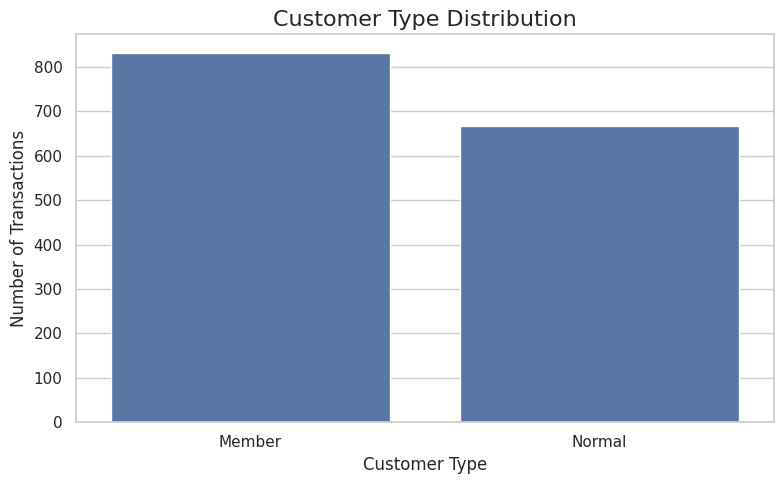

In [18]:
# 18. VISUALIZATION 3
# COUNT PLOT
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Customer_type"
)

plt.title(
    "Customer Type Distribution",
    fontsize=16
)

plt.xlabel("Customer Type")

plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.show()

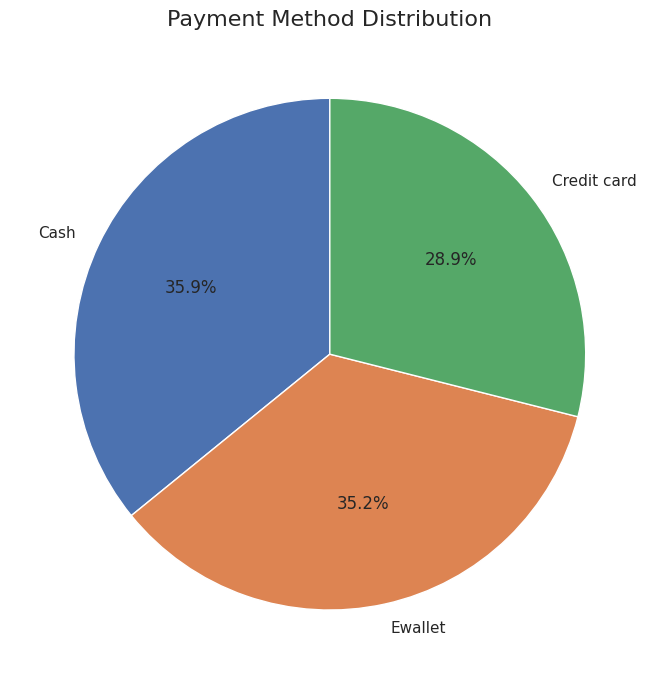

In [19]:
# 19. VISUALIZATION 4
# PIE CHART
# ============================================================

payment_counts = df["Payment"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Payment Method Distribution",
    fontsize=16
)

plt.tight_layout()

plt.show()


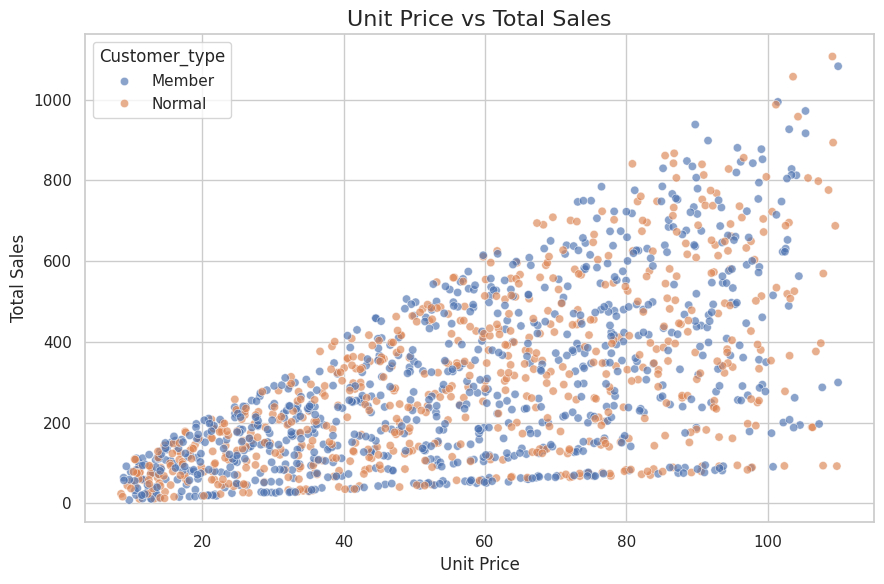

In [20]:
# 20. VISUALIZATION 5
# SCATTER PLOT
# ============================================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Unit_price",
    y="Total",
    hue="Customer_type",
    alpha=0.65
)

plt.title(
    "Unit Price vs Total Sales",
    fontsize=16
)

plt.xlabel("Unit Price")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()


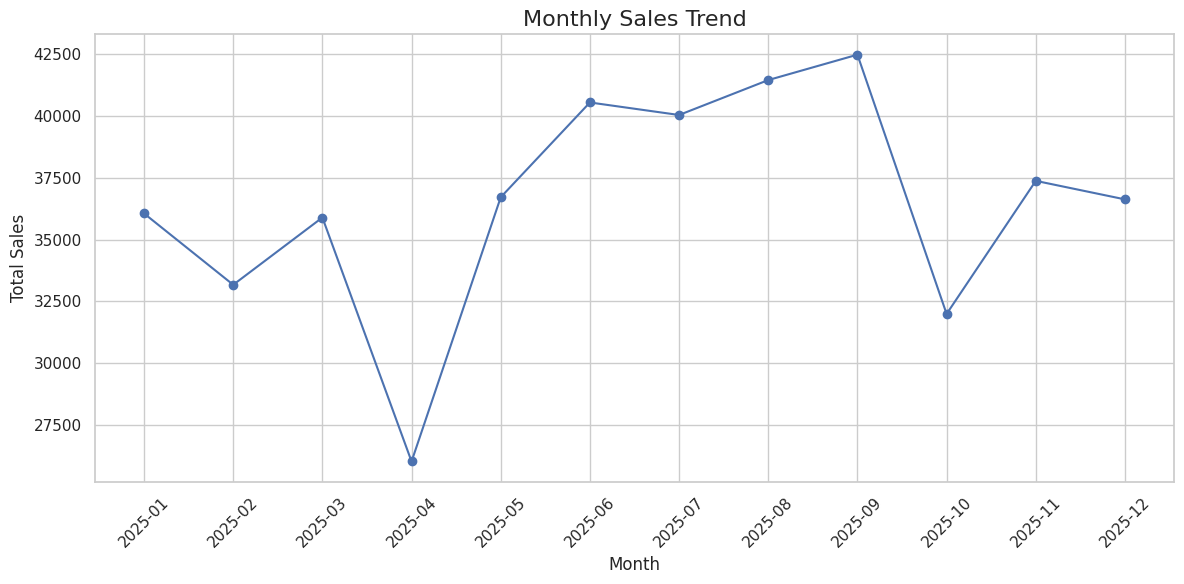

In [21]:
# 21. VISUALIZATION 6
# LINE CHART
# ============================================================

monthly_sales = (
    df.groupby(
        df["Date"].dt.to_period("M")
    )["Total"]
    .sum()
)

monthly_sales.index = (
    monthly_sales.index.astype(str)
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title(
    "Monthly Sales Trend",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


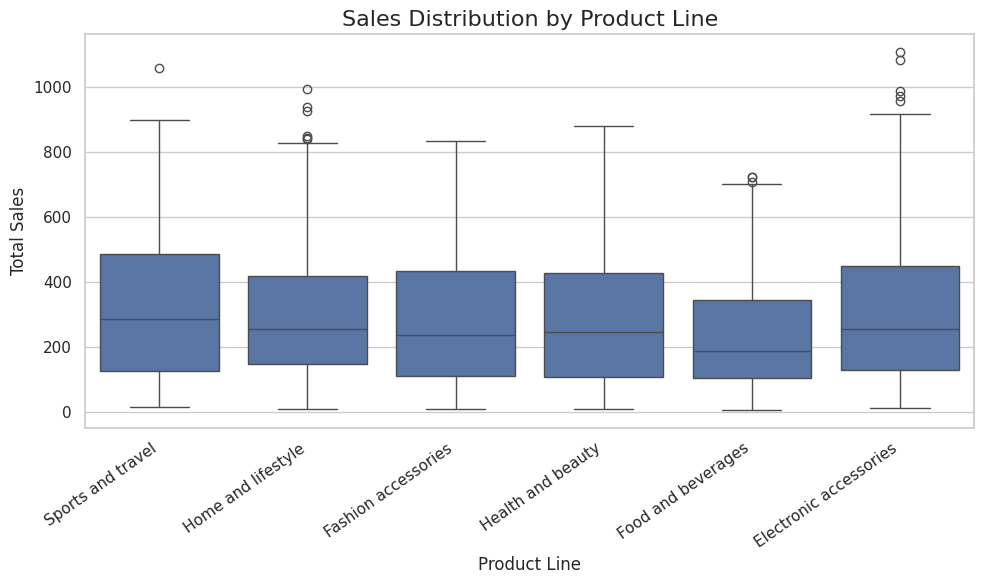

In [22]:
# 22. VISUALIZATION 7
# BOX PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Product_line",
    y="Total"
)

plt.title(
    "Sales Distribution by Product Line",
    fontsize=16
)

plt.xlabel("Product Line")

plt.ylabel("Total Sales")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()

plt.show()


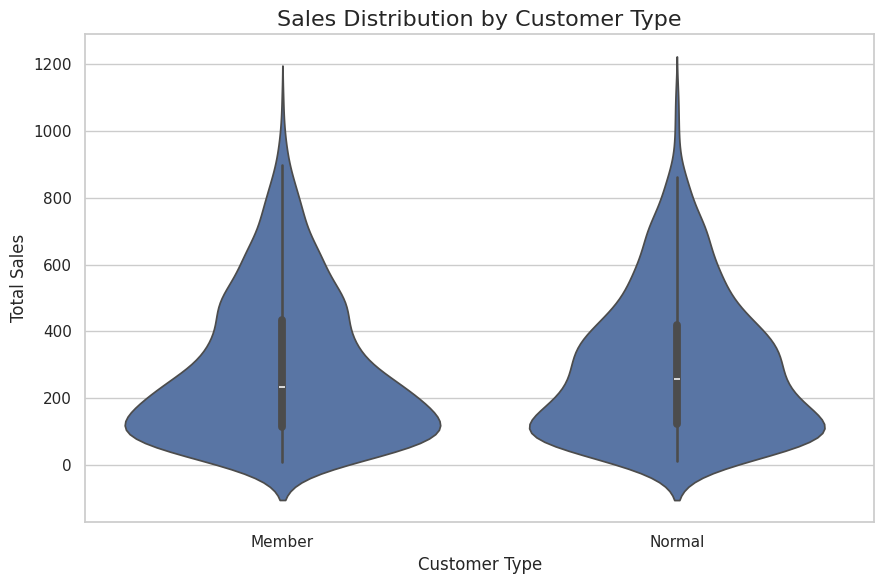

In [23]:
# 23. VISUALIZATION 8
# VIOLIN PLOT
# ============================================================

plt.figure(figsize=(9, 6))

sns.violinplot(
    data=df,
    x="Customer_type",
    y="Total"
)

plt.title(
    "Sales Distribution by Customer Type",
    fontsize=16
)

plt.xlabel("Customer Type")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()


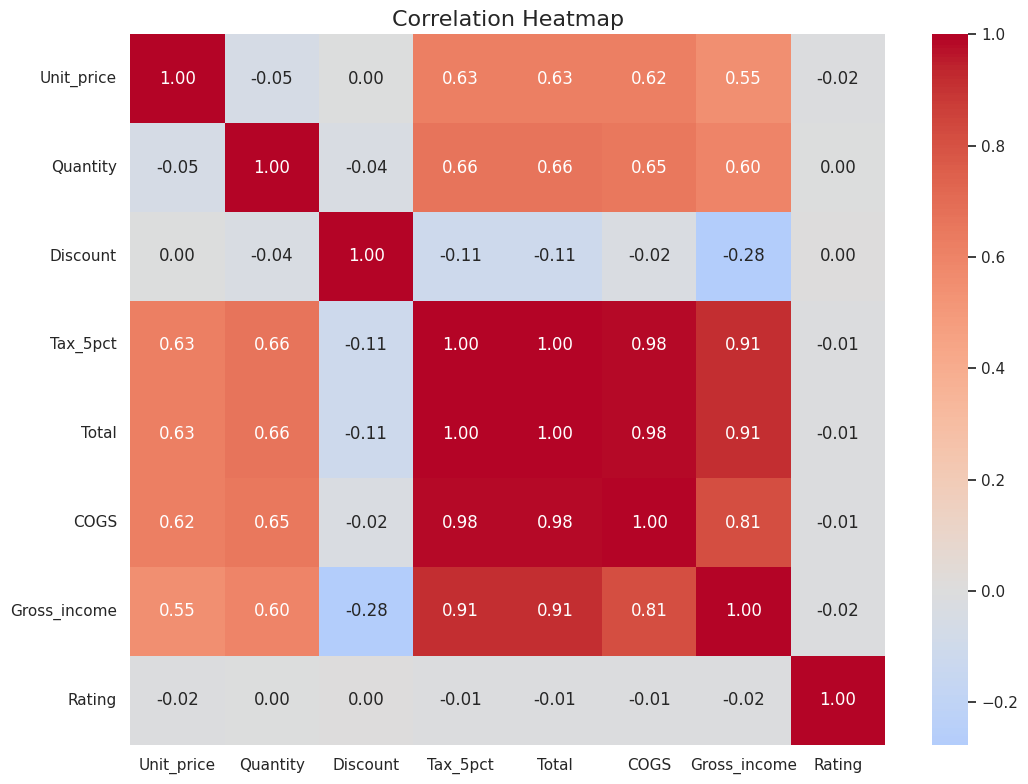

In [24]:
# 24. VISUALIZATION 9
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap",
    fontsize=16
)

plt.tight_layout()

plt.show()


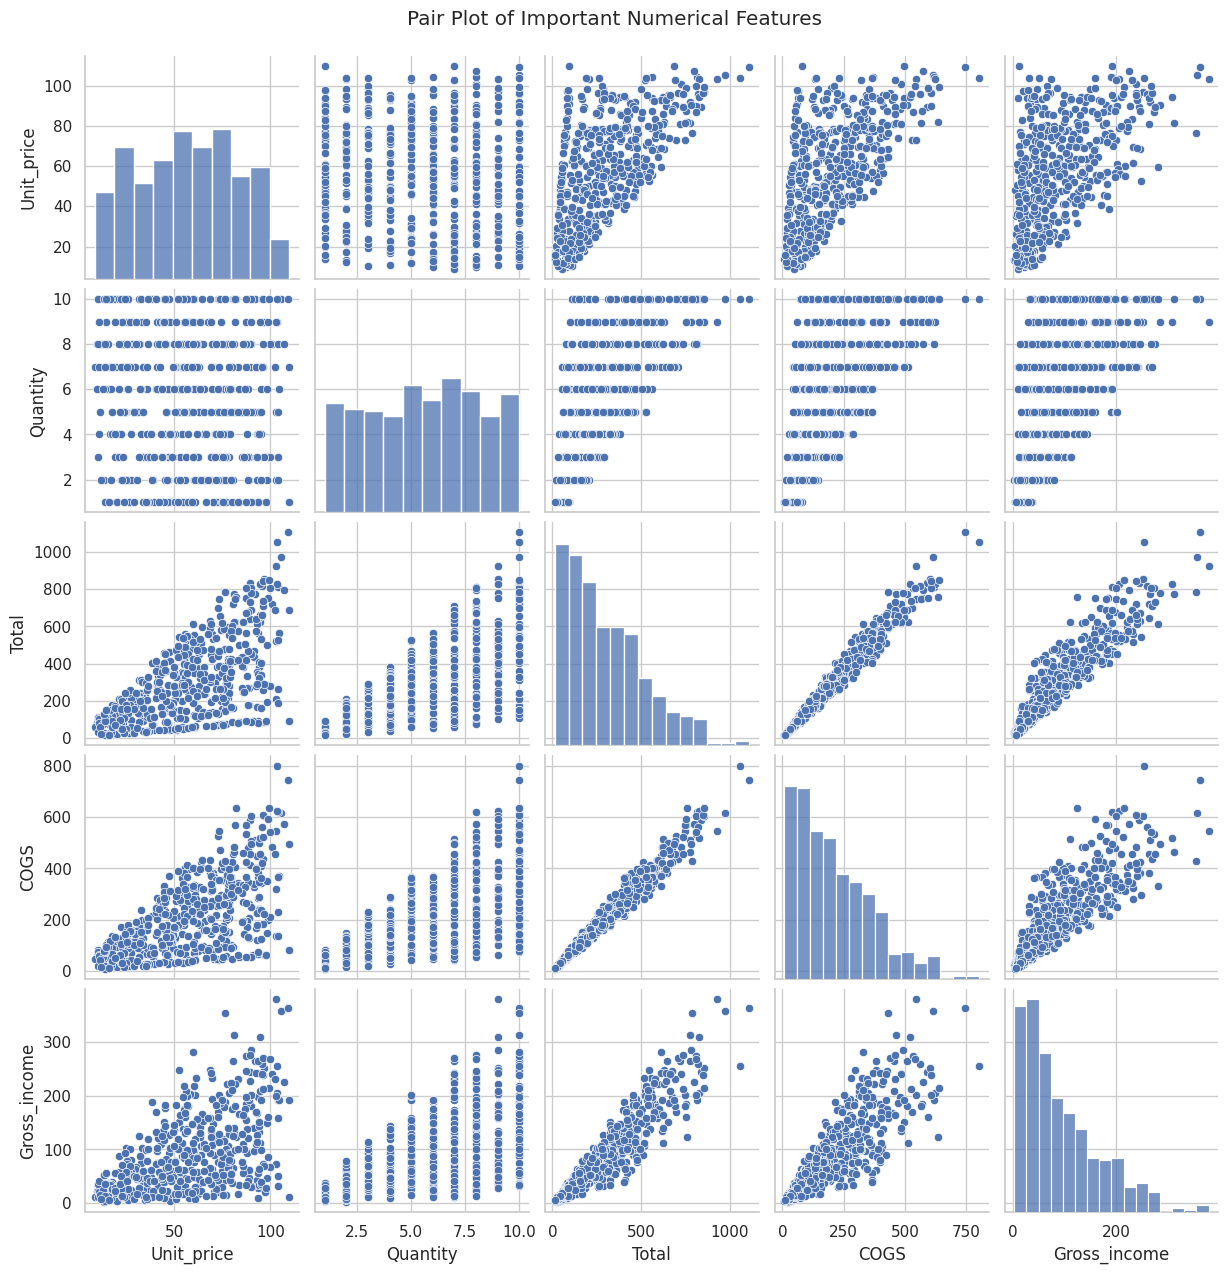

In [25]:
# 25. VISUALIZATION 10
# PAIR PLOT
# ============================================================

pair_columns = [
    "Unit_price",
    "Quantity",
    "Total",
    "COGS",
    "Gross_income"
]

pair_data = df[
    pair_columns
].sample(
    min(500, len(df)),
    random_state=42
)

sns.pairplot(
    pair_data
)

plt.suptitle(
    "Pair Plot of Important Numerical Features",
    y=1.02
)

plt.show()



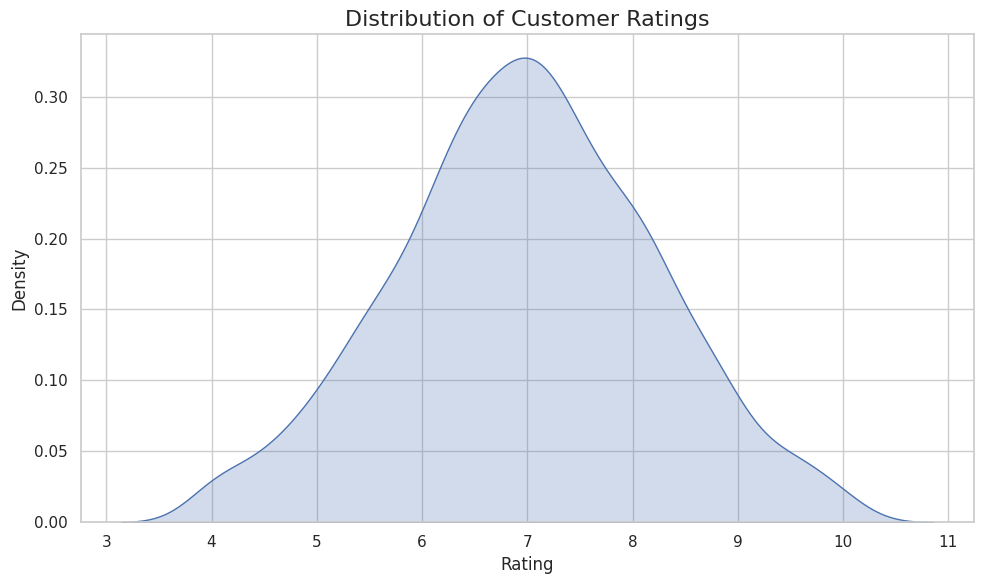

In [26]:
# 26. VISUALIZATION 11
# DISTRIBUTION PLOT
# ============================================================

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x="Rating",
    fill=True
)

plt.title(
    "Distribution of Customer Ratings",
    fontsize=16
)

plt.xlabel("Rating")

plt.ylabel("Density")

plt.tight_layout()

plt.show()

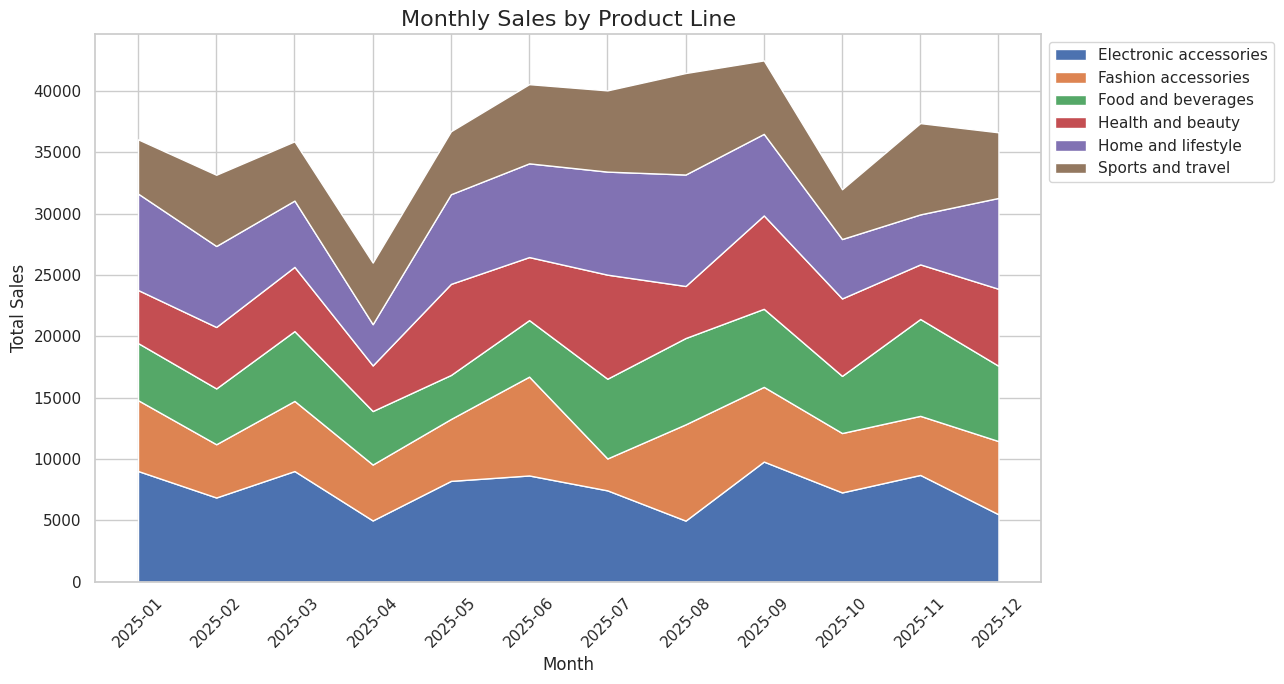

In [27]:
# 27. VISUALIZATION 12
# AREA CHART
# ============================================================

monthly_product = (
    df.groupby(
        [
            df["Date"].dt.to_period("M"),
            "Product_line"
        ]
    )["Total"]
    .sum()
    .unstack(
        fill_value=0
    )
)

monthly_product.index = (
    monthly_product.index.astype(str)
)

plt.figure(figsize=(13, 7))

plt.stackplot(
    monthly_product.index,
    *[
        monthly_product[column].values
        for column in monthly_product.columns
    ],
    labels=monthly_product.columns
)

plt.title(
    "Monthly Sales by Product Line",
    fontsize=16
)

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.xticks(
    rotation=45
)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1)
)

plt.tight_layout()

plt.show()

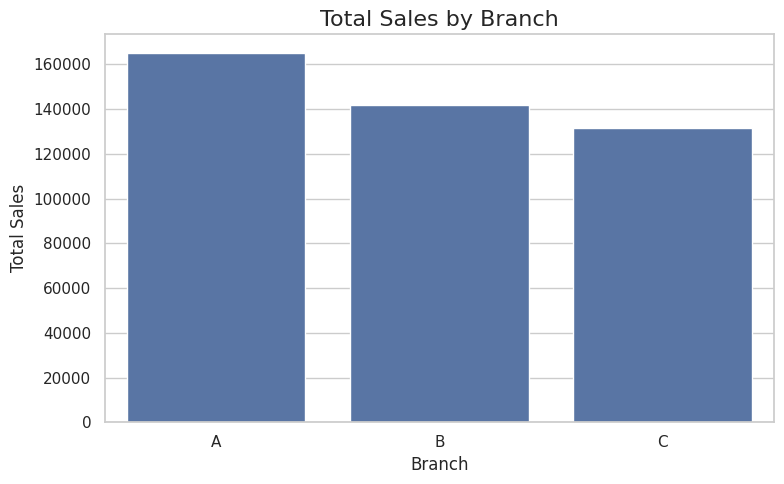

In [28]:
# ============================================================
# 28. VISUALIZATION 13
# BRANCH SALES
# ============================================================

branch_sales = (
    df.groupby("Branch")["Total"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=branch_sales.index,
    y=branch_sales.values
)

plt.title(
    "Total Sales by Branch",
    fontsize=16
)

plt.xlabel("Branch")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()


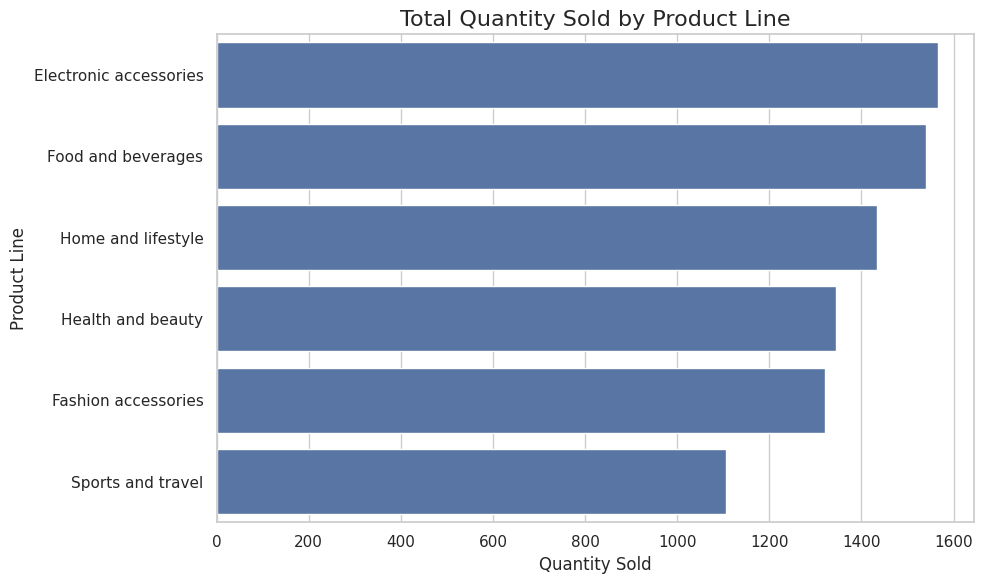

In [29]:
# 29. VISUALIZATION 14
# PRODUCT QUANTITY
# ============================================================

product_quantity = (
    df.groupby("Product_line")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=product_quantity.values,
    y=product_quantity.index
)

plt.title(
    "Total Quantity Sold by Product Line",
    fontsize=16
)

plt.xlabel("Quantity Sold")

plt.ylabel("Product Line")

plt.tight_layout()

plt.show()


In [31]:
# 31. BRANCH PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("BRANCH PERFORMANCE")
print("=" * 70)

branch_summary = (
    df.groupby(
        ["Branch", "City"]
    )
    .agg(
        Transactions=("Invoice_ID", "count"),
        Revenue=("Total", "sum"),
        Average_Sale=("Total", "mean"),
        Gross_Income=("Gross_income", "sum"),
        Average_Rating=("Rating", "mean")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

print(branch_summary)


BRANCH PERFORMANCE
                  Transactions    Revenue  Average_Sale  Gross_Income  \
Branch City                                                             
A      Yangon              549 165,120.71        300.77     50,431.05   
B      Mandalay            502 141,696.48        282.26     41,584.68   
C      Naypyitaw           449 131,531.12        292.94     39,338.84   

                  Average_Rating  
Branch City                       
A      Yangon               6.96  
B      Mandalay             7.01  
C      Naypyitaw            6.97  


In [32]:
# 32. CUSTOMER PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("CUSTOMER TYPE PERFORMANCE")
print("=" * 70)

customer_summary = (
    df.groupby("Customer_type")
    .agg(
        Transactions=("Invoice_ID", "count"),
        Revenue=("Total", "sum"),
        Average_Sale=("Total", "mean"),
        Average_Rating=("Rating", "mean")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

print(customer_summary)



CUSTOMER TYPE PERFORMANCE
               Transactions    Revenue  Average_Sale  Average_Rating
Customer_type                                                       
Member                  832 240,082.74        288.56            6.99
Normal                  668 198,265.57        296.80            6.96


In [33]:
# 33. PAYMENT PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("PAYMENT METHOD PERFORMANCE")
print("=" * 70)

payment_summary = (
    df.groupby("Payment")
    .agg(
        Transactions=("Invoice_ID", "count"),
        Revenue=("Total", "sum"),
        Average_Sale=("Total", "mean")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

print(payment_summary)



PAYMENT METHOD PERFORMANCE
             Transactions    Revenue  Average_Sale
Payment                                           
Ewallet               528 153,685.78        291.07
Cash                  538 152,536.57        283.53
Credit card           434 132,125.96        304.44


In [34]:
# 34. FIND IMPORTANT BUSINESS VALUES
# ============================================================

top_product = product_sales.idxmax()

top_product_sales = product_sales.max()

low_product = product_sales.idxmin()

low_product_sales = product_sales.min()

top_branch = branch_sales.idxmax()

top_branch_sales = branch_sales.max()

low_branch = branch_sales.idxmin()

low_branch_sales = branch_sales.min()

top_payment = payment_summary["Revenue"].idxmax()

top_customer_type = customer_summary["Revenue"].idxmax()

highest_avg_product = (
    product_summary["Average_Sale"].idxmax()
)

highest_avg_product_value = (
    product_summary["Average_Sale"].max()
)

lowest_avg_product = (
    product_summary["Average_Sale"].idxmin()
)

lowest_avg_product_value = (
    product_summary["Average_Sale"].min()
)

best_rating_product = (
    product_summary["Average_Rating"].idxmax()
)

best_rating = (
    product_summary["Average_Rating"].max()
)

highest_quantity_product = (
    product_summary["Quantity_Sold"].idxmax()
)

highest_quantity = (
    product_summary["Quantity_Sold"].max()
)

lowest_quantity_product = (
    product_summary["Quantity_Sold"].idxmin()
)

lowest_quantity = (
    product_summary["Quantity_Sold"].min()
)

best_month = monthly_sales.idxmax()

best_month_sales = monthly_sales.max()

worst_month = monthly_sales.idxmin()

worst_month_sales = monthly_sales.min()

average_revenue = df["Total"].mean()

average_rating = df["Rating"].mean()

total_revenue = df["Total"].sum()



In [35]:
# 35. 15 BUSINESS INSIGHTS
# ============================================================

print("\n" + "=" * 70)
print("15 BUSINESS INSIGHTS")
print("=" * 70)

insights = [

f"1. {top_product} generated the highest total revenue of {top_product_sales:,.2f}.",

f"2. {low_product} generated the lowest total revenue of {low_product_sales:,.2f}.",

f"3. Branch {top_branch} recorded the highest total revenue of {top_branch_sales:,.2f}.",

f"4. Branch {low_branch} recorded the lowest total revenue of {low_branch_sales:,.2f}.",

f"5. {top_payment} was the payment method contributing the highest revenue.",

f"6. {top_customer_type} customers generated the highest total revenue among customer types.",

f"7. {highest_avg_product} had the highest average transaction value of {highest_avg_product_value:,.2f}.",

f"8. {lowest_avg_product} had the lowest average transaction value of {lowest_avg_product_value:,.2f}.",

f"9. {best_rating_product} had the highest average customer rating of {best_rating:.2f}.",

f"10. {highest_quantity_product} had the highest total quantity sold at {highest_quantity:,} units.",

f"11. {lowest_quantity_product} had the lowest total quantity sold at {lowest_quantity:,} units.",

f"12. {best_month} was the strongest month by revenue with {best_month_sales:,.2f}.",

f"13. {worst_month} was the weakest month by revenue with {worst_month_sales:,.2f}.",

f"14. The overall average transaction value was {average_revenue:,.2f}.",

f"15. The overall average customer rating was {average_rating:.2f} out of 10."

]

for insight in insights:

    print(insight)


15 BUSINESS INSIGHTS
1. Electronic accessories generated the highest total revenue of 90,552.97.
2. Fashion accessories generated the lowest total revenue of 65,615.61.
3. Branch A recorded the highest total revenue of 165,120.71.
4. Branch C recorded the lowest total revenue of 131,531.12.
5. Ewallet was the payment method contributing the highest revenue.
6. Member customers generated the highest total revenue among customer types.
7. Sports and travel had the highest average transaction value of 330.36.
8. Food and beverages had the lowest average transaction value of 237.48.
9. Health and beauty had the highest average customer rating of 7.06.
10. Electronic accessories had the highest total quantity sold at 1,566 units.
11. Sports and travel had the lowest total quantity sold at 1,106 units.
12. 2025-09 was the strongest month by revenue with 42,483.16.
13. 2025-04 was the weakest month by revenue with 26,012.30.
14. The overall average transaction value was 292.23.
15. The overa

In [36]:
# 36. 5 BUSINESS RECOMMENDATIONS
# ============================================================

print("\n" + "=" * 70)
print("5 BUSINESS RECOMMENDATIONS")
print("=" * 70)

recommendations = [

f"1. Increase promotional and inventory attention for {top_product} because it generated the highest revenue.",

f"2. Review the pricing, promotion, and product mix of {low_product} because it generated the lowest revenue.",

f"3. Study the successful practices of Branch {top_branch} and compare them with Branch {low_branch}.",

f"4. Encourage the use of the strongest-performing payment channel, {top_payment}, while continuing to support alternative payment methods.",

f"5. Use monthly sales patterns to plan inventory and marketing campaigns before strong months and investigate the causes of weak months."

]

for recommendation in recommendations:

    print(recommendation)


5 BUSINESS RECOMMENDATIONS
1. Increase promotional and inventory attention for Electronic accessories because it generated the highest revenue.
2. Review the pricing, promotion, and product mix of Fashion accessories because it generated the lowest revenue.
3. Study the successful practices of Branch A and compare them with Branch C.
4. Encourage the use of the strongest-performing payment channel, Ewallet, while continuing to support alternative payment methods.
5. Use monthly sales patterns to plan inventory and marketing campaigns before strong months and investigate the causes of weak months.


In [37]:
# 37. SAVE ANALYSIS TABLES
# ============================================================

product_summary.to_csv(
    "product_line_summary.csv"
)

branch_summary.to_csv(
    "branch_summary.csv"
)

customer_summary.to_csv(
    "customer_type_summary.csv"
)

payment_summary.to_csv(
    "payment_summary.csv"
)

In [38]:
# 38. FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL PROJECT CHECK")
print("=" * 70)

print(
    "Total Records:",
    len(df)
)

print(
    "Total Columns:",
    len(df.columns)
)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Records:",
    df.duplicated().sum()
)

print(
    "Total Revenue:",
    f"{total_revenue:,.2f}"
)

print(
    "Average Rating:",
    f"{average_rating:.2f}"
)

print("\n14 Visualizations Created")
print("15 Business Insights Generated")
print("5 Business Recommendations Generated")

print("\n" + "=" * 70)
print("EDA TASK COMPLETED SUCCESSFULLY!")
print("=" * 70)


FINAL PROJECT CHECK
Total Records: 1500
Total Columns: 22
Missing Values: 0
Duplicate Records: 0
Total Revenue: 438,348.31
Average Rating: 6.98

14 Visualizations Created
15 Business Insights Generated
5 Business Recommendations Generated

EDA TASK COMPLETED SUCCESSFULLY!


In [30]:
# 30. PRODUCT PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("PRODUCT PERFORMANCE")
print("=" * 70)

product_summary = (
    df.groupby("Product_line")
    .agg(
        Transactions=("Invoice_ID", "count"),
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Total", "sum"),
        Average_Sale=("Total", "mean"),
        Average_Rating=("Rating", "mean"),
        Gross_Income=("Gross_income", "sum")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

print(product_summary)


PRODUCT PERFORMANCE
                        Transactions  Quantity_Sold   Revenue  Average_Sale  \
Product_line                                                                  
Electronic accessories           287           1566 90,552.97        315.52   
Home and lifestyle               259           1433 78,598.63        303.47   
Sports and travel                210           1106 69,376.18        330.36   
Health and beauty                233           1344 68,184.53        292.64   
Food and beverages               278           1541 66,020.39        237.48   
Fashion accessories              233           1320 65,615.61        281.61   

                        Average_Rating  Gross_Income  
Product_line                                          
Electronic accessories            7.02     26,949.21  
Home and lifestyle                6.98     24,138.06  
Sports and travel                 6.89     20,470.90  
Health and beauty                 7.06     20,401.45  
Food and beverag